In [1]:
import csv

#import dzcnapy_plotlib as dzcnapy
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from networkx.algorithms import bipartite

%matplotlib inline
plt.rcParams['figure.figsize'] = [15, 10]

/usr/local/Cellar/python/3.6.5_1/Frameworks/Python.framework/Versions/3.6/lib/python3.6/importlib/_bootstrap.py:219: RuntimeWarning: numpy.dtype size changed, may indicate binary incompatibility. Expected 96, got 88
  return f(*args, **kwds)


/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:522: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if not cb.is_string_like(edge_color) \
/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:543: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if cb.is_string_like(edge_color) or len(edge_color) == 1:
/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:724: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if not cb.is_string_like(label):


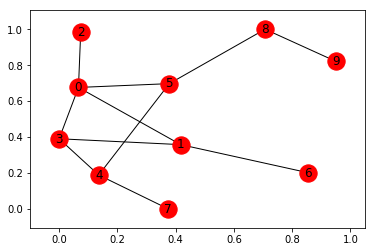

In [2]:
G = nx.Graph()

G.add_edges_from([(0, 1), (0, 2), (0, 3), (0, 5), 
                  (1, 3), (1, 6),
                  (3, 4),
                  (4, 5),(4, 7),
                  (5, 8),
                  (8, 9)])
nx.draw_networkx(G)

### Adjacency List

In [3]:
!cat data/G_adjlist.txt

0 1 2 3 5
1 3 6
2
3 4
4 5 7
5 8
6
7
8 9
9


[('0', '1'), ('0', '2'), ('0', '3'), ('0', '5'), ('1', '3'), ('1', '6'), ('3', '4'), ('5', '4'), ('5', '8'), ('4', '7'), ('8', '9')]


/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:522: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if not cb.is_string_like(edge_color) \
/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:543: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if cb.is_string_like(edge_color) or len(edge_color) == 1:
/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:724: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if not cb.is_string_like(label):


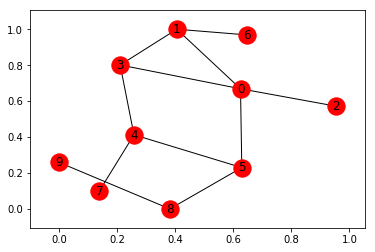

In [4]:
G = nx.read_adjlist('data/G_adjlist.txt')
print(G.edges())
nx.draw_networkx(G)

### Adjacency Matrix

[(0, 1), (0, 2), (0, 3), (0, 5), (1, 3), (1, 6), (3, 4), (4, 5), (4, 7), (5, 8), (8, 9)]


/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:522: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if not cb.is_string_like(edge_color) \
/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:543: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if cb.is_string_like(edge_color) or len(edge_color) == 1:
/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:724: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if not cb.is_string_like(label):


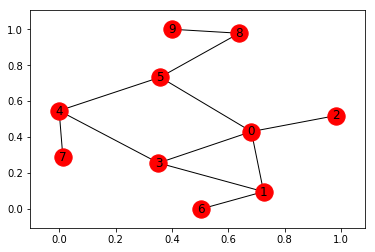

In [5]:
G_mat = np.array([[0, 1, 1, 1, 0, 1, 0, 0, 0, 0],
                  [1, 0, 0, 1, 0, 0, 1, 0, 0, 0],
                  [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                  [1, 1, 0, 0, 1, 0, 0, 0, 0, 0],
                  [0, 0, 0, 1, 0, 1, 0, 1, 0, 0],
                  [1, 0, 0, 0, 1, 0, 0, 0, 1, 0],
                  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                  [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                  [0, 0, 0, 0, 0, 1, 0, 0, 0, 1],
                  [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]])
G = nx.Graph(G_mat)
print(G.edges())
nx.draw_networkx(G)

### Edgelist

In [6]:
!cat data/G_edgelist.txt

0 1 4
0 2 3
0 3 2
0 5 6
1 3 2
1 6 5
3 4 3
4 5 1
4 7 2
5 8 6
8 9 1


Interpretation: 
```
Edge 0 -> 1 has weight = 4
```
or more generally 
```
Edge 0 -> 1 has an attribute with value = 4
```

[('0', '1', {'Weight': 4}), ('0', '2', {'Weight': 3}), ('0', '3', {'Weight': 2}), ('0', '5', {'Weight': 6}), ('1', '3', {'Weight': 2}), ('1', '6', {'Weight': 5}), ('3', '4', {'Weight': 3}), ('5', '4', {'Weight': 1}), ('5', '8', {'Weight': 6}), ('4', '7', {'Weight': 2}), ('8', '9', {'Weight': 1})]


/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:522: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if not cb.is_string_like(edge_color) \
/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:543: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if cb.is_string_like(edge_color) or len(edge_color) == 1:
/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:724: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if not cb.is_string_like(label):


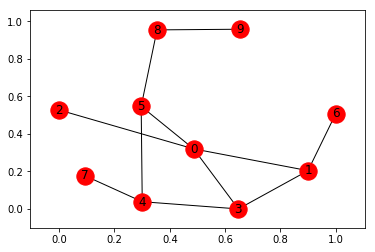

In [7]:
G = nx.read_edgelist('data/G_edgelist.txt', data=[('Weight', int)])
print(G.edges(data=True))
nx.draw_networkx(G)

### Pandas DataFrame

In [8]:
G_df = pd.read_csv('data/G_edgelist.txt', 
                   delim_whitespace=True, 
                   header=None, 
                   names=['n1', 'n2', 'weight'])
G_df.head()

,n1,n2,weight
0,0,1,4
1,0,2,3
2,0,3,2
3,0,5,6
4,1,3,2


[(0, 1, {'weight': 4}), (0, 2, {'weight': 3}), (0, 3, {'weight': 2}), (0, 5, {'weight': 6}), (1, 3, {'weight': 2}), (1, 6, {'weight': 5}), (3, 4, {'weight': 3}), (5, 4, {'weight': 1}), (5, 8, {'weight': 6}), (4, 7, {'weight': 2}), (8, 9, {'weight': 1})]


/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:522: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if not cb.is_string_like(edge_color) \
/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:543: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if cb.is_string_like(edge_color) or len(edge_color) == 1:
/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:724: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if not cb.is_string_like(label):


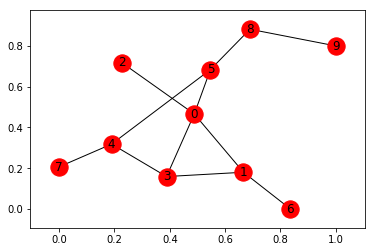

In [9]:
G = nx.from_pandas_dataframe(G_df, 'n1', 'n2', edge_attr='weight')
print(G.edges(data=True))
nx.draw_networkx(G)

In [10]:
G.degree()

{0: 4, 1: 3, 2: 1, 3: 3, 5: 3, 6: 1, 4: 3, 7: 1, 8: 2, 9: 1}

# Practice

In [11]:
employees = set([
    'Pablo', 'Lee', 'Georgia', 'Vincent', 'Andy', 'Frida', 'Joan', 
    'Claude'])
movies = set([
    'The Shawshank Redemption', 'Forrest Gump', 'The Matrix', 'Anaconda',
    'The Social Network', 'The Godfather', 
    'Monty Python and the Holy Grail', 'Snakes on a Plane', 
    'Kung Fu Panda', 'The Dark Knight', 'Mean Girls'])

In [12]:
def plot_graph(G, weight_name=None):
    plt.figure()
    pos = nx.spring_layout(G)
    edges = G.edges()
    
    if weight_name:
        #weights = [int(G[i][j]) for i, j in edges]
        weights = [e[2][weight_name] for e in G.edges(data=True)]
        #labels = nx.get_edge_attributes(G, weight_name)
        nx.draw_networkx_edge_labels(G, pos, edge_labels=weights)
        nx.draw_networkx(G, pos, edges=edges, width=weights)
    else:
        nx.draw_networkx(G, pos, edges=edges)

In [13]:
def load_and_display_movies():
    G_df = pd.read_csv('data/employee_movie_choices.txt', 
                       delimiter='\t')
    G_df.head()
    G = nx.from_pandas_dataframe(G_df, 'Employee', 'Movie')
    plot_graph(G)
    
    return G

/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:522: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if not cb.is_string_like(edge_color) \
/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:543: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if cb.is_string_like(edge_color) or len(edge_color) == 1:
/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:724: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if not cb.is_string_like(label):


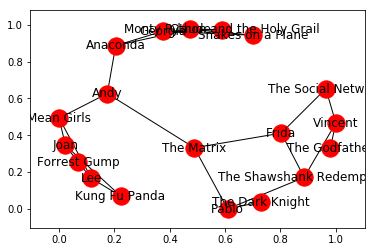

In [14]:
G = load_and_display_movies()

In [15]:
def add_type_to_graph(G):
    for node in G.nodes():
        n_type = 'employee' if node in employees else 'movie'
        nx.set_node_attributes(G, 'type', n_type)
    return G

In [16]:
G = add_type_to_graph(G)

In [17]:
G.nodes(data=True)

[('Andy', {'type': 'movie'}),
 ('Anaconda', {'type': 'movie'}),
 ('Mean Girls', {'type': 'movie'}),
 ('The Matrix', {'type': 'movie'}),
 ('Claude', {'type': 'movie'}),
 ('Monty Python and the Holy Grail', {'type': 'movie'}),
 ('Snakes on a Plane', {'type': 'movie'}),
 ('Frida', {'type': 'movie'}),
 ('The Shawshank Redemption', {'type': 'movie'}),
 ('The Social Network', {'type': 'movie'}),
 ('Georgia', {'type': 'movie'}),
 ('Joan', {'type': 'movie'}),
 ('Forrest Gump', {'type': 'movie'}),
 ('Kung Fu Panda', {'type': 'movie'}),
 ('Lee', {'type': 'movie'}),
 ('Pablo', {'type': 'movie'}),
 ('The Dark Knight', {'type': 'movie'}),
 ('Vincent', {'type': 'movie'}),
 ('The Godfather', {'type': 'movie'})]

In [18]:
def similarity_graph(G, n_type):
    G = bipartite.weighted_projected_graph(G, n_type)
    edges = G.edges()
    weights = [e[2]['weight'] for e in G.edges(data=True)]
    plt.figure();
    pos = nx.spring_layout(G)
    nx.draw_networkx(G, pos, edges=edges, width=weights)

/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:522: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if not cb.is_string_like(edge_color) \
/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:543: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if cb.is_string_like(edge_color) or len(edge_color) == 1:
/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:724: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if not cb.is_string_like(label):


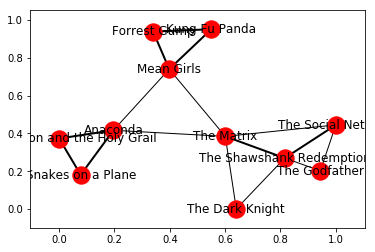

In [19]:
similarity_graph(G, movies)

/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:522: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if not cb.is_string_like(edge_color) \
/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:543: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if cb.is_string_like(edge_color) or len(edge_color) == 1:
/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:724: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if not cb.is_string_like(label):


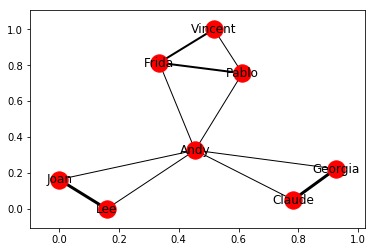

In [20]:
similarity_graph(G, employees)

In [21]:
with open('data/nutrients.csv') as f:
    csv_reader = csv.reader(f)
    G = nx.Graph(csv_reader)
    
G.nodes()

['A',
 'carrots',
 'eggs',
 'fatty fish',
 'green leafy vegs',
 'liver',
 'milk',
 'tomatoes',
 'B12',
 'B6',
 'asparagus',
 'beans',
 'shellfish',
 'Se',
 'thiamin',
 'whole grains',
 'veg oils',
 'E',
 'yogurt',
 'Ca']

In [22]:
# Remove self-loops
loops = list(G.selfloop_edges())
G.remove_edges_from(loops)
print(loops)

[('tomatoes', 'tomatoes')]


/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:522: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if not cb.is_string_like(edge_color) \
/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:543: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if cb.is_string_like(edge_color) or len(edge_color) == 1:
/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:724: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if not cb.is_string_like(label):


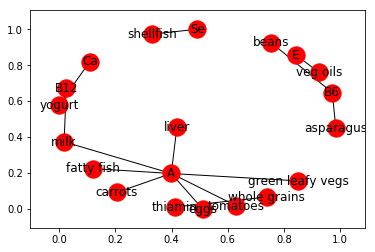

In [23]:
plot_graph(G)

/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:522: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if not cb.is_string_like(edge_color) \
/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:543: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if cb.is_string_like(edge_color) or len(edge_color) == 1:
/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:724: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if not cb.is_string_like(label):


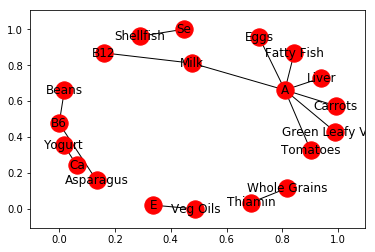

In [24]:
# Capitalize node names
mapping = {node: node.title() for node in G if isinstance(node, str)}
nx.relabel_nodes(G, mapping, copy=False)
nx.draw_networkx(G)

In [25]:
G['A']

{'Carrots': {},
 'Eggs': {},
 'Fatty Fish': {},
 'Green Leafy Vegs': {},
 'Liver': {},
 'Milk': {},
 'Tomatoes': {}}

In [27]:
# Add attributes
G.add_node('Honey', edible=True)
G.add_nodes_from([('Steel', {'edible': False}),])
G.add_edge('Honey', 'Steel', weight=0.)
G.add_edges_from([('Honey', 'Zn'),], related=False)

In [28]:
G.add_weighted_edges_from([('Honey', 'Zn', 0.01), 
                           ('Honey', 'Sugar', 0.99)])

In [29]:
#nx.set_node_attributes(G, node_dict, att_name)
#nx.set_edge_attributes(G, edge_dict, att_name)

In [32]:
#G.nodes['Zn']['nutrient'] = True
#G.edges[('Zn', 'Beef')]['weight'] = 0.95

In [33]:
print(G.nodes(data=True))

[('A', {}), ('B12', {}), ('B6', {}), ('Se', {}), ('E', {}), ('Ca', {}), ('Carrots', {}), ('Eggs', {}), ('Fatty Fish', {}), ('Green Leafy Vegs', {}), ('Liver', {}), ('Milk', {}), ('Tomatoes', {}), ('Asparagus', {}), ('Beans', {}), ('Shellfish', {}), ('Thiamin', {}), ('Whole Grains', {}), ('Veg Oils', {}), ('Yogurt', {}), ('Honey', {'edible': True}), ('Steel', {'edible': False}), ('Zn', {}), ('Sugar', {})]


/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:522: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if not cb.is_string_like(edge_color) \
/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:543: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if cb.is_string_like(edge_color) or len(edge_color) == 1:
/usr/local/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:724: MatplotlibDeprecationWarning: The is_string_like function was deprecated in version 2.1.
  if not cb.is_string_like(label):


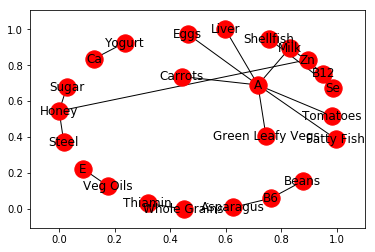

In [34]:
plot_graph(G)